In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report

In [13]:
# Membuat dataset
data = {
    'IPK': [3.5, 2.8, 3.2],
    'SKS': [22, 18, 20],
    'Status': [1, 0, 1]
}

df = pd.DataFrame(data)

print("=== DATASET MAHASISWA ===")
display(df)

=== DATASET MAHASISWA ===


,IPK,SKS,Status
0,3.5,22,1
1,2.8,18,0
2,3.2,20,1


In [14]:
print("=== RUMUS PERCEPTRON ===")
print("z = w1*x1 + w2*x2 + b")
print("y = 1 jika z >= 0")
print("y = 0 jika z < 0")

# data pertama
x1 = 3.5
x2 = 22

w1 = 1
w2 = 1
b = -20

z = (w1*x1) + (w2*x2) + b
y = 1 if z >= 0 else 0

print("\n=== PERHITUNGAN DATA PERTAMA ===")
print("z =", z)
print("Output y =", y)

=== RUMUS PERCEPTRON ===
z = w1*x1 + w2*x2 + b
y = 1 jika z >= 0
y = 0 jika z < 0

=== PERHITUNGAN DATA PERTAMA ===
z = 5.5
Output y = 1


In [15]:
X = df[['IPK', 'SKS']]
y = df['Status']

model = Perceptron(
    max_iter=100,
    eta0=0.1,
    random_state=42,
    tol=1e-3
)

model.fit(X, y)

print("=== RIWAYAT TRAINING ===")
print("Jumlah iterasi :", model.n_iter_)
print("Bobot (weight):", model.coef_[0])
print("Bias :", model.intercept_[0])

=== RIWAYAT TRAINING ===
Jumlah iterasi : 9
Bobot (weight): [0.28 1.4 ]
Bias : 0.0


In [16]:
df['Hasil_Prediksi'] = model.predict(X)

print("=== HASIL PREDIKSI ===")
display(df)

print("\n=== EVALUASI ===")
print(classification_report(
    df['Status'],
    df['Hasil_Prediksi'],
    zero_division=0
))

=== HASIL PREDIKSI ===


,IPK,SKS,Status,Hasil_Prediksi
0,3.5,22,1,1
1,2.8,18,0,1
2,3.2,20,1,1



=== EVALUASI ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



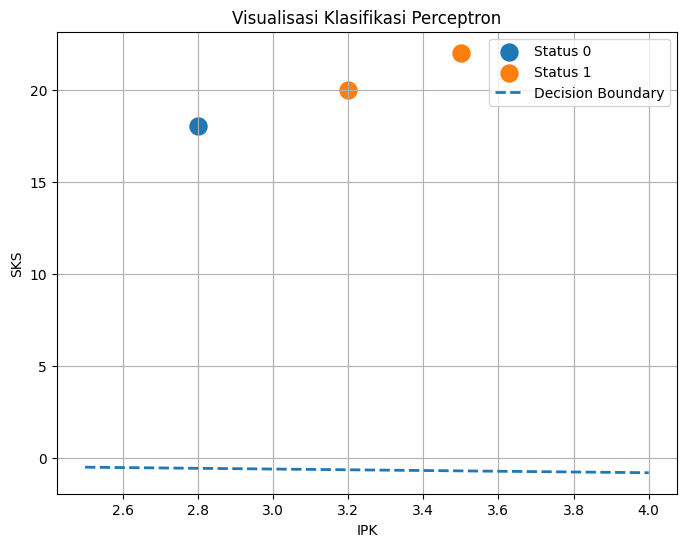

In [17]:
plt.figure(figsize=(8,6))

warna = ['red', 'blue']

for status in [0,1]:
    subset = df[df['Status']==status]
    
    plt.scatter(
        subset['IPK'],
        subset['SKS'],
        s=150,
        label=f'Status {status}'
    )

# garis decision boundary
w = model.coef_[0]
b = model.intercept_[0]

x_line = np.linspace(2.5, 4.0, 100)
y_line = -(w[0]*x_line + b)/w[1]

plt.plot(
    x_line,
    y_line,
    '--',
    linewidth=2,
    label='Decision Boundary'
)

plt.xlabel("IPK")
plt.ylabel("SKS")
plt.title("Visualisasi Klasifikasi Perceptron")
plt.legend()
plt.grid(True)

plt.show()